# Diferencia Significativa Valor de P

* Quiero saber si existe diferencia significativa (cuando mensionamos esto aparece el concepto de valor de P)
* Quiero saber si existe diferencia significativa en el peso de los niños al nacer de las mamás vegetarianas y las mamas que no son vegetarianas
* Quiero saber si existe diferencia significativa en el puntaje de los examenes de matematica de los niños que van a los colegios publicos vs de los que van a los colegios privados
* Quiero saber si existe diferencia significativa en la resistencia del papel que se hace con la madera A, de la resistencia que se hace con la madera B
* Quiero saber si se vende mas el pan salado o el dulce ( es decir si el sabor del pan influye sobre las ventas)
* quiero saber si el color de mi pagina web influye sobre la cantidad de clicks que dan en la pagina web
* quiero saber si porque tengo la opcion de pago por paypal en mi pagina web vendo mas
* Quiero saber si  las escobas hechas con el material A son mas resistentes que las del material B
* Quiero saber si la raza de ganado A produce mas leche que la raza B

Como vemos podemos imaginar varios ejemplos donde es util aplicar el concepto del valor de P. Pero realmente en sucede que un jefe de nos pedira los siguiente:
* ¿Vale la pena cambiar esto?
* ¿Gano o pierdo dinero?
* ¿El cambio es real o solo ruido?
* ¿Puedo tomar una decisión con esto?

El valor de P es solo una herramienta, no es la respuesta.

El objetivo es tomar decisiones con un buen respaldo, tomando en cuenta lo siguiente:
* Si la diferencia importa en dinero
* Si el efecto es estable en el tiempo
* Si la muestra es representativa
* Si hay variables de confusión
* Si la decisión es reversible o no

lograremos responder la siguiente pregunta: ***¿Este cambio produce un efecto suficientemente grande, confiable y accionable como para tomar una decisión?***

# El valor de P en T-TEST y ANOVA
#### Ahora lo que veremos a continuación es establecer una evidencia paar esas diferencias de una variable de interes entre 2 grupos, y luego extenderlo a 3 o mas grupos, para ello contamos con dos metodologias T-TEST y ANOVA.
##### * T-TEST: se utiliza cuando se compara 2 grupo, se usa cuando se quiere comprobar si dos medias son realmente diferentes o si la diferencia se debe al azar.
##### * ANOVA: se utiliza cuando se compara 3 o mas grupos

# T-TEST (Ejemplo Discriminacion de Precios)

## Hypothesis

$$ H_{0} : \mu_{nurse} = \mu_{doctor}$$
$$ H_{a} : \mu_{nurse} \neq \mu_{doctor}$$

* Lo que vamos a optener es un valor de P, este valor es la evidencia en contra o a favor de que el precio de las barbies enfermeras es igual al precio de las barbies doctoras. **Si p es menor que 0.05 se rechaza la hipótesis nula.**
* Es decir vamos a responder a la pregunta: ¿Que tan probable es de observar los datos si la idea es verdadera respecto a la idea de que el precio de las barbies enfermeras es igual a al precio de las barbies doctoras?

### Supuestos
* Las observaciones son independientes entre grupos: es decir una barbie no tiene nada que ver con la otra, son independientes, son muestras aleatorias que se tomo de la población, no me sesgue en solo analizar los precios de mercado libre.
* Las dos variables deben distribuirse de forma normal.
* Los tipos de datos (variables) tienen que ser semejantes y operacionales, es decir no puedo evaluar por ejemplo años donde por ejemplo no puedo dividir (2008años/2002años)
* Ambas poblaciones deben tener la misma desviación estandar (homocedasticidad), para que nuestro T-TES sea mas robusto respecto al cumplimiento de este supuesto es importante aplicar Welch t-test directamente (ver mas adelante)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import seaborn as sns

In [4]:
url_barbies_price = "https://raw.githubusercontent.com/it-ces/Datasets/refs/heads/main/barbies_prices.csv"
df_barbies_prices = pd.read_csv(url_barbies_price)

In [5]:
df_barbies_prices.head()

,price,job
0,89591.234959,Doctor
1,126423.101675,Doctor
2,96162.078714,Doctor
3,90724.919537,Doctor
4,75536.576945,Doctor


In [10]:
#Verifiquimos cuantos datos tenemos en total
df_barbies_prices['job'].value_counts()

job
Doctor    130
Nurse     130
Name: count, dtype: int64

### Analizando si las dos variables se distribuyen de formal normal

<Axes: xlabel='job', ylabel='price'>

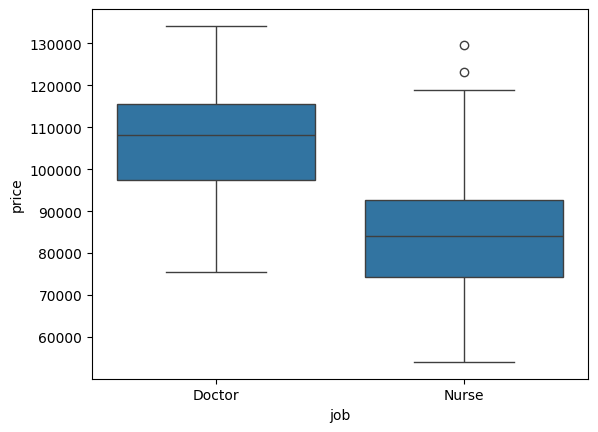

In [ ]:
#Grafico de cajas para visualizar la distribucion de los precios por cada trabajo
sns.boxplot(data=df_barbies_prices, x = 'job', y = 'price')

Nos da indicio de que la varible es igual de ancha y que tiene posiblemente tenga un comportamiento normal debido a su distribución

(array([ 7.,  4., 11., 17., 19., 15., 27., 13., 10.,  7.]),
 array([ 75536.5769454 ,  81399.64320885,  87262.70947231,  93125.77573577,
         98988.84199922, 104851.90826268, 110714.97452614, 116578.04078959,
        122441.10705305, 128304.17331651, 134167.23957996]),
 <BarContainer object of 10 artists>)

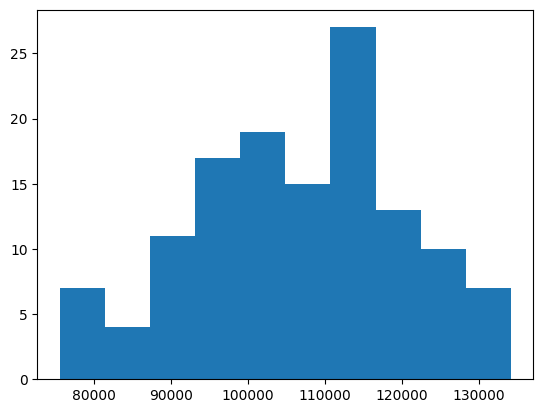

In [7]:
plt.hist(df_barbies_prices[df_barbies_prices['job']=='Doctor']['price'])

(array([ 3., 17., 21., 26., 25., 21.,  9.,  4.,  2.,  2.]),
 array([ 54037.13374525,  61588.61337129,  69140.09299732,  76691.57262336,
         84243.0522494 ,  91794.53187544,  99346.01150147, 106897.49112751,
        114448.97075355, 122000.45037958, 129551.93000562]),
 <BarContainer object of 10 artists>)

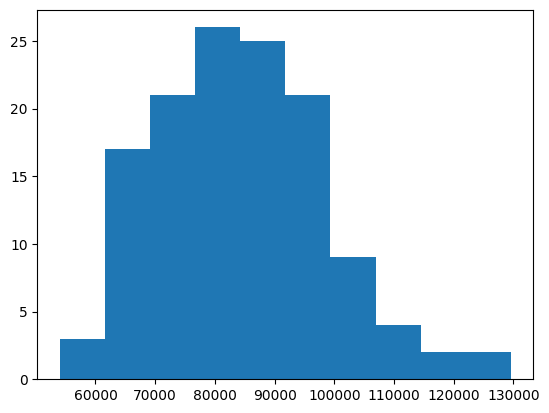

In [8]:
plt.hist(df_barbies_prices[df_barbies_prices['job']=='Nurse']['price'])

((array([-2.55445479, -2.22902648, -2.0419783 , -1.90719589, -1.80015121,
         -1.71047373, -1.63275826, -1.56381343, -1.50159038, -1.44469181,
         -1.39212017, -1.3431372 , -1.29718048, -1.2538112 , -1.21268003,
         -1.17350409, -1.13605091, -1.10012698, -1.06556939, -1.03223961,
         -1.00001877, -0.96880405, -0.93850586, -0.90904562, -0.88035396,
         -0.85236935, -0.82503685, -0.79830725, -0.77213622, -0.74648367,
         -0.72131321, -0.69659166, -0.67228871, -0.64837651, -0.62482945,
         -0.60162387, -0.57873784, -0.55615102, -0.53384444, -0.51180041,
         -0.49000234, -0.46843466, -0.44708273, -0.42593273, -0.40497157,
         -0.38418687, -0.36356684, -0.34310027, -0.32277642, -0.30258504,
         -0.28251629, -0.2625607 , -0.24270913, -0.22295275, -0.20328303,
         -0.18369165, -0.16417053, -0.14471177, -0.12530767, -0.10595063,
         -0.08663321, -0.06734807, -0.04808795, -0.02884566, -0.00961403,
          0.00961403,  0.02884566,  0.

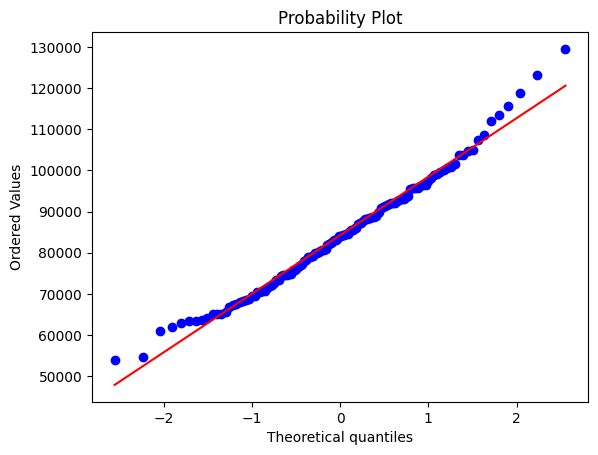

In [ ]:
#Evaluemos la normalidad de los datos con QQ-Plot
#Doctor
scipy.stats.probplot(df_barbies_prices[df_barbies_prices['job']=='Nurse']['price'], dist='norm', plot=plt)

In [ ]:
#Nurse
scipy.stats.probplot(df_barbies_prices[df_barbies_prices['job']=='Nurse']['price'], dist='norm', plot=plt)

* Si la variable es completamente normal la mayoria de los puntos azules se va ajustar sobre la linea roja
* Ecntonces **al parecer las variables son normales.**
* Pero para confirmar esto podemos utilizar el **test de shapiro wilk que evalua si la distribución es normal, su hipotesis nula es que X se distribuye de forma normal y su hipotesis alternativa indica de que no es normal** Si el obtenido es mayor al nivel de significancia seleccionado (ej. 0.05), no hay evidencia para rechazar, lo que implica normalidad

In [12]:
#Test Shapiro-Wilk
print(scipy.stats.shapiro(df_barbies_prices[df_barbies_prices['job']=='Doctor']['price']).pvalue)
print(scipy.stats.shapiro(df_barbies_prices[df_barbies_prices['job']=='Nurse']['price']).pvalue)

0.22088205153326246
0.13534945960358996


Entonces concluimos que son tanto los datos de Nurse y Doctor son normales

# Levene test

Levene test: verifica si la varianza (dispersión) de dos o más grupos es igual o diferente. Como la desviación estándar es la raíz de la varianza, si las varianzas son iguales entonces las desviaciones estándar también lo serán.

Interpretación: si p > 0.05 → varianzas (y desviaciones estándar) similares; si p ≤ 0.05 → varianzas (y desviaciones estándar) diferentes.


$$ H_{0} : \sigma_{nurse} = \sigma_{doctor}$$
$$ H_{a} : \sigma_{nurse} \neq \sigma_{doctor}$$

* H₀ (hipótesis nula):
las varianzas de los grupos son iguales

* H₁ (hipótesis alternativa):
al menos una varianza es diferente

En otras palabras, verifica homocedasticidad.

* p > 0.05 → no hay evidencia de varianzas diferentes
→ puedes asumir varianzas iguales

* p ≤ 0.05 → las varianzas probablemente son distintas
→ hay heterocedasticidad

In [9]:
scipy.stats.levene(df_barbies_prices[df_barbies_prices['job'] == 'Doctor']['price'],
                   df_barbies_prices[df_barbies_prices['job'] == 'Nurse']['price'], center='mean').pvalue

np.float64(0.9636360680617045)

##### **Conclusión**:
El valor de p nos da 0.96, la varianza de los grupos de datos son iguales, entonces **concluimos de que los datos de la barbie enfermera y medica tienen el mismo ancho, casi la misma desviación estandar**.

##### **Importante**:
* Levene se usa solo en temas academicos para documentas supuestos, un analisis estadistico formal.
* En el **data science aplicado a la industria se usa directamente Welch --- "scipy.stats.ttest_ind(grupo_A, grupo_B, equal_var=False)"**

# T-TEST

$$ H_{0} : \mu_{nurse} = \mu_{doctor}$$
$$ H_{a} : \mu_{nurse} \neq \mu_{doctor}$$

**Si p es menor que 0.05 se rechaza la hipótesis nula.**

Regla importante del T-test

El p-value disminuye cuando:

1️⃣ aumenta la diferencia de medias
2️⃣ disminuye la variabilidad (desviación estandar)
3️⃣ aumenta el tamaño de muestra

Un detalle muy importante (que muchos interpretan mal)

Decir:

* “no hay evidencia de diferencia”

NO significa

* “las medias son iguales”.

Significa solo:

* los datos no son suficientes para demostrar una diferencia.

Puede pasar por varias razones:

- la diferencia es pequeña

- hay mucha variabilidad

- la muestra es pequeña

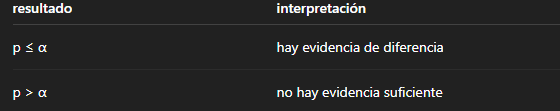

Tenemos dos tipos de T-TEST: 
* **Independent t-test (ttest_ind)**: Se usa cuando comparas dos grupos que NO están relacionados.
* **Paired t-test (ttest_rel)**: Se usa cuando comparas el mismo equipo antes y después de algo.

Para el caso de las barbies, se usa independent t-test porque el precio de las Nurse no esta relacionado con el precio de las Doctor. Tenemos "Price Nurse vs Price Doctor"

In [13]:
scipy.stats.ttest_ind(df_barbies_prices[df_barbies_prices['job']=='Doctor']['price'],
                      df_barbies_prices[df_barbies_prices['job']=='Nurse']['price'], equal_var=False).pvalue

np.float64(9.398787711566765e-30)

##### **Conclusión**
Tenemos un valor de p=9.39e-30 que es menor a 0.05, lo que me indica que tengo evidencia para pensar de que realmente hay discrimación de precio, es decir **hay diferencia entre los precios de las Nurse y Doctor.**